# Feature Engineering — Segmentação de Crédito

## Objetivo
Preparar os dados para clustering através de transformações
que garantam que o algoritmo capture comportamentos reais
e não seja distorcido por escala ou redundância.

## Pipeline
1. Transformação Logarítmica
2. Padronização (StandardScaler)
3. Redução de Dimensionalidade (PCA)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

df = pd.read_csv('../data/raw/CC GENERAL.csv')

# Reaplicando tratamento de nulos
df['CREDIT_LIMIT'] = df['CREDIT_LIMIT'].fillna(df['CREDIT_LIMIT'].median())
df['MINIMUM_PAYMENTS'] = df['MINIMUM_PAYMENTS'].fillna(df['MINIMUM_PAYMENTS'].median())

# Removendo ID
df_clean = df.drop(columns=['CUST_ID'])

print(f"Shape: {df_clean.shape}")
print("Dados carregados!")

Shape: (8950, 17)
Dados carregados!


## 1. Transformação Logarítmica

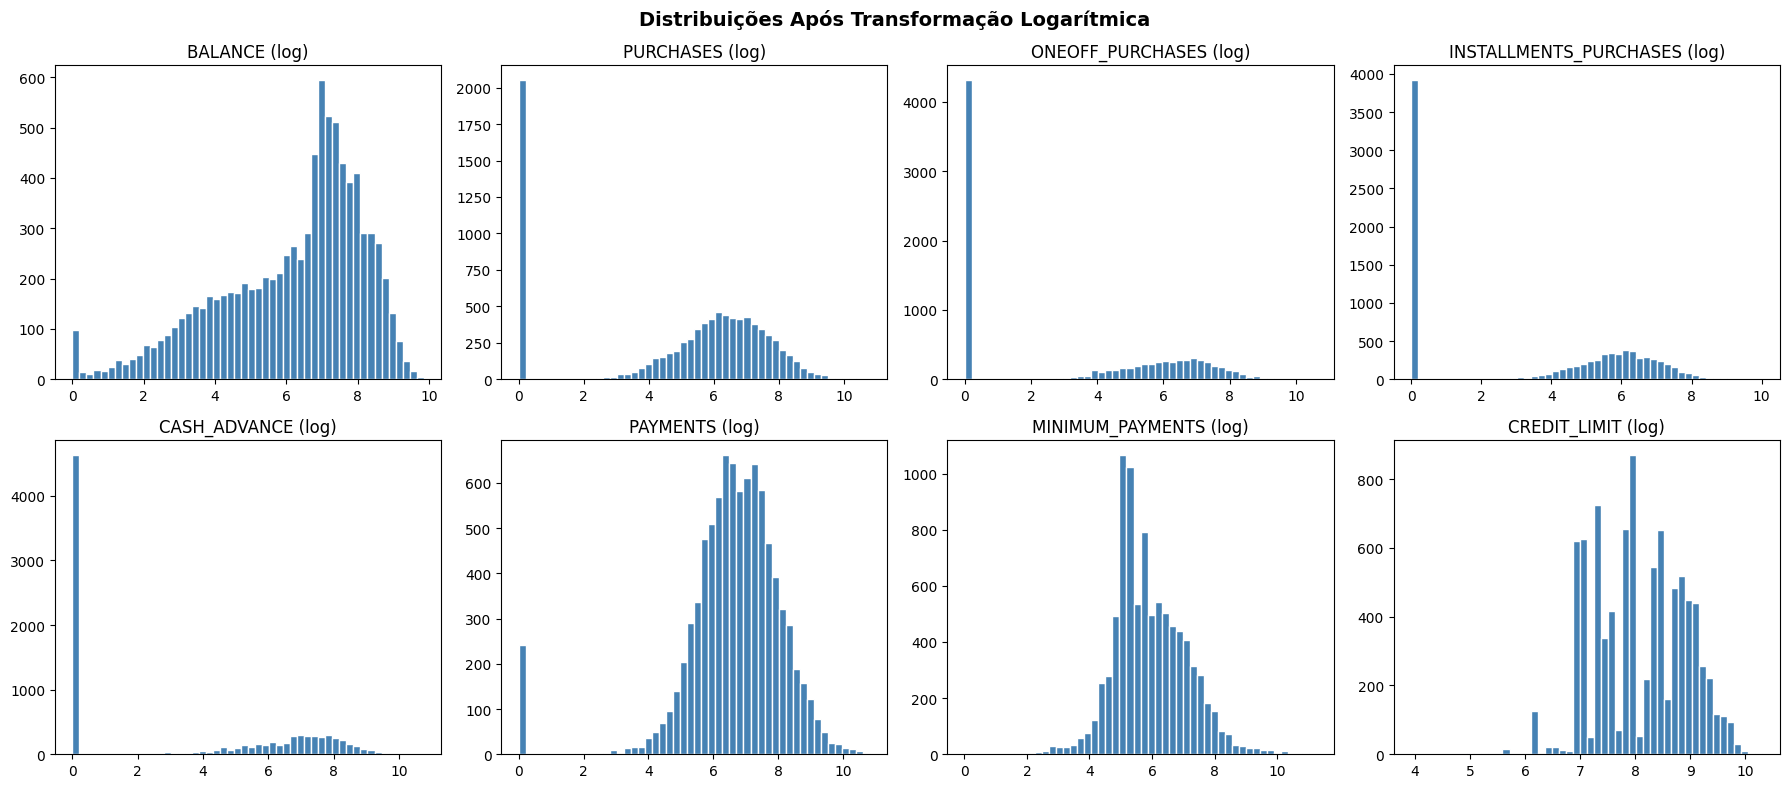

Transformação logarítmica aplicada!


In [2]:
# Colunas financeiras com assimetria
cols_log = ['BALANCE', 'PURCHASES', 'ONEOFF_PURCHASES', 
            'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE',
            'PAYMENTS', 'MINIMUM_PAYMENTS', 'CREDIT_LIMIT']

df_log = df_clean.copy()

for col in cols_log:
    df_log[col] = np.log1p(df_clean[col])

# Comparando antes e depois
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(cols_log):
    axes[i].hist(df_log[col], bins=50, color='steelblue', edgecolor='white')
    axes[i].set_title(f'{col} (log)')

plt.suptitle('Distribuições Após Transformação Logarítmica', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Transformação logarítmica aplicada!")

## 2. Padronização

In [3]:
scaler = StandardScaler()
df_scaled = pd.DataFrame(
    scaler.fit_transform(df_log),
    columns=df_log.columns
)

print("Estatísticas após padronização:")
print(df_scaled.describe().round(2))

Estatísticas após padronização:
       BALANCE  BALANCE_FREQUENCY  PURCHASES  ONEOFF_PURCHASES  \
count  8950.00            8950.00    8950.00           8950.00   
mean      0.00               0.00       0.00              0.00   
std       1.00               1.00       1.00              1.00   
min      -3.06              -3.70      -1.68             -0.99   
25%      -0.65               0.05      -0.41             -0.99   
50%       0.30               0.52       0.34              0.14   
75%       0.73               0.52       0.72              0.97   
max       1.83               0.52       2.02              2.28   

       INSTALLMENTS_PURCHASES  CASH_ADVANCE  PURCHASES_FREQUENCY  \
count                 8950.00       8950.00              8950.00   
mean                     0.00          0.00                -0.00   
std                      1.00          1.00                 1.00   
min                     -1.09         -0.93                -1.22   
25%                     -1.09    

## 3. Redução de Dimensionalidade (PCA)

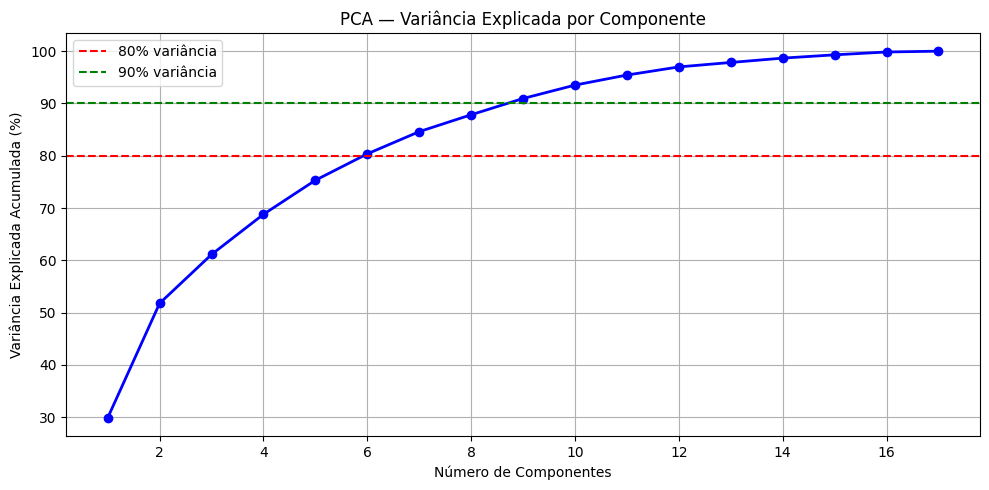

Componente  1: 29.9% | Acumulado: 29.9%
Componente  2: 21.9% | Acumulado: 51.8%
Componente  3: 9.3% | Acumulado: 61.1%
Componente  4: 7.7% | Acumulado: 68.8%
Componente  5: 6.5% | Acumulado: 75.3%
Componente  6: 5.0% | Acumulado: 80.4%
Componente  7: 4.2% | Acumulado: 84.6%
Componente  8: 3.2% | Acumulado: 87.8%
Componente  9: 3.1% | Acumulado: 90.9%

→ 9 componentes explicam 90% da variância


In [4]:
# Aplicando PCA com todas as componentes primeiro
pca_full = PCA()
pca_full.fit(df_scaled)

# Variância explicada acumulada
variancia_acumulada = np.cumsum(pca_full.explained_variance_ratio_) * 100

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(variancia_acumulada) + 1), 
         variancia_acumulada, 'bo-', linewidth=2)
plt.axhline(y=80, color='red', linestyle='--', label='80% variância')
plt.axhline(y=90, color='green', linestyle='--', label='90% variância')
plt.xlabel('Número de Componentes')
plt.ylabel('Variância Explicada Acumulada (%)')
plt.title('PCA — Variância Explicada por Componente')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Tabela de variância por componente
for i, var in enumerate(pca_full.explained_variance_ratio_ * 100):
    acum = variancia_acumulada[i]
    print(f"Componente {i+1:2d}: {var:.1f}% | Acumulado: {acum:.1f}%")
    if acum >= 90:
        print(f"\n→ {i+1} componentes explicam 90% da variância")
        break

In [5]:
# Aplicando PCA com 6 componentes
N_COMPONENTS = 6

pca = PCA(n_components=N_COMPONENTS)
df_pca = pca.fit_transform(df_scaled)

# Transformando em DataFrame
cols_pca = [f'PC{i+1}' for i in range(N_COMPONENTS)]
df_pca = pd.DataFrame(df_pca, columns=cols_pca)

print(f"Shape original: {df_scaled.shape}")
print(f"Shape após PCA: {df_pca.shape}")
print(f"\nVariância explicada: {pca.explained_variance_ratio_.sum()*100:.1f}%")
print(f"\nPrimeiras linhas:")
print(df_pca.head())

Shape original: (8950, 17)
Shape após PCA: (8950, 6)

Variância explicada: 80.4%

Primeiras linhas:
        PC1       PC2       PC3       PC4       PC5       PC6
0 -0.551286 -2.545012 -0.309568 -0.875060 -0.118496 -0.133603
1 -2.948913  1.237305  0.032686 -0.231854  1.597123  0.662144
2  1.351829  1.229987  2.684535 -0.919355 -0.672339  0.105291
3 -1.217276 -1.094976  1.875784 -0.610212 -1.336007 -2.397574
4 -1.264395 -1.074701  0.791396 -1.550921 -0.167143  0.915928


## 4. Interpretando os Componentes PCA

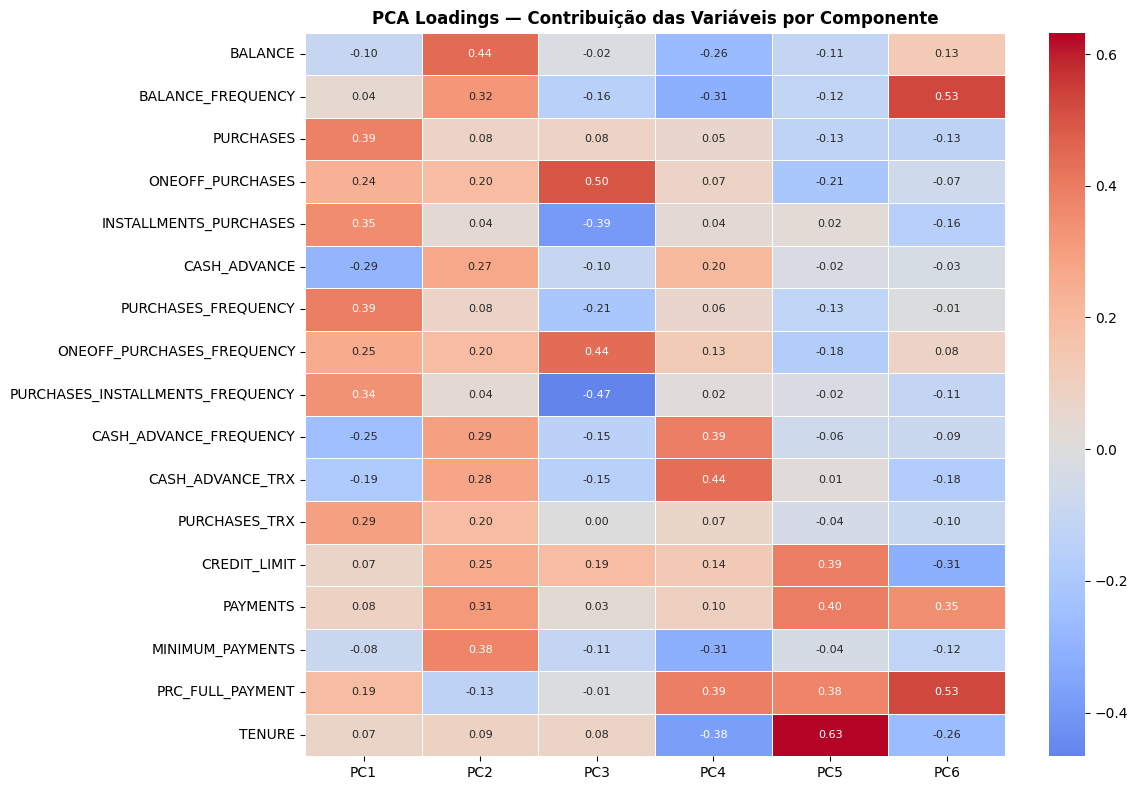

In [6]:
# Loadings — contribuição de cada variável para cada componente
loadings = pd.DataFrame(
    pca.components_.T,
    columns=cols_pca,
    index=df_scaled.columns
)

plt.figure(figsize=(12, 8))
sns.heatmap(loadings, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, annot_kws={'size': 8})
plt.title('PCA Loadings — Contribuição das Variáveis por Componente',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [7]:
import joblib

# Salva dados para modelagem
df_pca.to_csv('../data/processed/df_pca.csv', index=False)
df_scaled.to_csv('../data/processed/df_scaled.csv', index=False)

# Salva objetos para deploy
joblib.dump(scaler, '../models/scaler.pkl')
joblib.dump(pca, '../models/pca.pkl')

print("Arquivos salvos!")
print("  - data/processed/df_pca.csv")
print("  - data/processed/df_scaled.csv")
print("  - models/scaler.pkl")
print("  - models/pca.pkl")

Arquivos salvos!
  - data/processed/df_pca.csv
  - data/processed/df_scaled.csv
  - models/scaler.pkl
  - models/pca.pkl
